In [48]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from torch import optim
import copy
import numpy as np

In [49]:
print(torch.__version__)

2.5.1+cu118


In [50]:
print(torch.cuda.is_available())  # It will be true if gpu is usable
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

In [52]:
# Transform for training and testing
# The images are resized to 150x150 pixels and converted to tensors
transform_train = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
])


In [53]:
# Dataset preparation

def get_data_loaders(batch_size, num_workers=2):
    train_dataset = datasets.ImageFolder("food11/train", transform=transform_train)
    val_dataset = datasets.ImageFolder("food11/validation", transform=transform_test)
    test_dataset = datasets.ImageFolder("food11/test", transform=transform_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader


In [75]:
# Model definition
# The model is a convolutional neural network with 5 convolutional blocks, each followed by batch normalization and ReLU activation functions.
# After the convolutional layers, there is a dropout layer to reduce overfitting, followed by an adaptive average pooling layer and two fully connected layers.
# The final output layer has 11 units, corresponding to the 11 classes in the dataset.
# The model uses ReLU activation functions and dropout for regularization.
# The model is designed to classify images into 11 different classes, which are food categories in this case.

class CNN(nn.Module):
    def __init__(self, num_classes=11):
        super(CNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # 150 -> 75
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # 75 -> 37
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # 37 -> 18
        )

        self.conv_block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # 18 -> 9
            
        )

        self.dropout = nn.Dropout(0.5)  # Dropout layer after conv layers for reducing overfitting


        # Adaptive Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected layer
        self.fc = nn.Sequential(
            nn.Flatten(),             # 512 * 1 * 1 = 512
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.conv_block5(x)
        x = self.dropout(x)          # Dropout again
        x = self.gap(x)
        x = self.fc(x)
        return x

In [76]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, save_path, device):
    model.train()  # select training mode

    criterion = nn.CrossEntropyLoss()  # loss function
    # optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5) # Adam optimizer, more advanced but leads to overfitting. 

    # SGD optimizer, more basic but less overfitting
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-5)


    train_acc_list = []
    val_acc_list = []
    best_val_acc = 0

    # Training loop
    for epoch in range(epochs):
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)  # load images and labels to GPU

            optimizer.zero_grad()  # resetting gradients to zero
            outputs = model(images)  # model prediction
            loss = criterion(outputs, labels)  # calculate loss
            loss.backward()  # backpropagation
            optimizer.step()  # update weights

            # calculate training accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = correct_train / total_train
        train_acc_list.append(train_acc)

        # validation accuracy
        correct_val = 0
        total_val = 0
        model.eval()  # evaluation mode
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)  # load images and labels to GPU
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = correct_val / total_val
        val_acc_list.append(val_acc)

        # Record the best accuracy model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)  # Record the best model

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return train_acc_list, val_acc_list, best_val_acc


In [77]:
# Main function to run the training and evaluation

def evaluate_model(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


In [79]:
# Testing and evaluation
def test_model(model_path="model.pth", batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # just take the test loader
    _, _, test_loader =  get_data_loaders(batch_size, num_workers=2)

    model = CNN(num_classes=11)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n Test Accuracy: {acc:.4f}")

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=[
        'apple_pie', 'cheesecake', 'chicken_curry', 'french_fries',
        'fried_rice', 'hamburger', 'hot_dog', 'ice_cream',
        'omelette', 'pizza', 'sushi'
    ]))


In [30]:
# Main function to run the training and evaluation
# def main():
def main(): 

    learning_rates = [0.001, 0.005, 0.01]
    batch_sizes = [32, 64]
    num_epochs = 50

    results = []

    # Set the device to GPU if available, otherwise CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for batch_size in batch_sizes:
        for lr in learning_rates:
            print(f"\n Training with batch size={batch_size}, learning rate={lr}")

            # load data
            train_loader, val_loader, _ = get_data_loaders(batch_size, num_workers=2)

            # create model
            model = CNN(num_classes=11)
            model.to(device)

            # start training
            save_path = f"model_bs{batch_size}_lr{lr}.pth"
            train_acc_list, val_acc_list, best_val_acc = train_model(
                model,
                train_loader,
                val_loader,
                epochs=num_epochs,
                learning_rate=lr,
                save_path=save_path,
                device=device
            )

            # keep track of results
            results.append({
                "batch_size": batch_size,
                "learning_rate": lr,
                "train_acc_list": train_acc_list,
                "val_acc_list": val_acc_list,
                "best_val_acc": best_val_acc
            })

if __name__ == "__main__":
    main()



 Training with batch size=32, learning rate=0.001
Epoch [1/50], Loss: 2.2806, Train Acc: 0.1323, Val Acc: 0.2145
Epoch [2/50], Loss: 2.2359, Train Acc: 0.2150, Val Acc: 0.1709
Epoch [3/50], Loss: 2.0859, Train Acc: 0.2282, Val Acc: 0.2182
Epoch [4/50], Loss: 2.2451, Train Acc: 0.2395, Val Acc: 0.2618
Epoch [5/50], Loss: 2.2169, Train Acc: 0.2614, Val Acc: 0.1891
Epoch [6/50], Loss: 2.0497, Train Acc: 0.2873, Val Acc: 0.2836
Epoch [7/50], Loss: 2.0433, Train Acc: 0.2868, Val Acc: 0.2945
Epoch [8/50], Loss: 1.9893, Train Acc: 0.2818, Val Acc: 0.2764
Epoch [9/50], Loss: 2.1250, Train Acc: 0.3182, Val Acc: 0.2545
Epoch [10/50], Loss: 1.6076, Train Acc: 0.3232, Val Acc: 0.3091
Epoch [11/50], Loss: 2.3029, Train Acc: 0.3377, Val Acc: 0.3236
Epoch [12/50], Loss: 2.0857, Train Acc: 0.3477, Val Acc: 0.3600
Epoch [13/50], Loss: 1.7397, Train Acc: 0.3495, Val Acc: 0.3382
Epoch [14/50], Loss: 1.7330, Train Acc: 0.3582, Val Acc: 0.3564
Epoch [15/50], Loss: 1.7019, Train Acc: 0.3550, Val Acc: 0.360

In [82]:
def plot_results(epochs, train_acc, val_acc, title):
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


C:\Users\YusufEmirComert\AppData\Local\Temp\ipykernel_20080\1761897833.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_l


 Test Accuracy: 0.4509


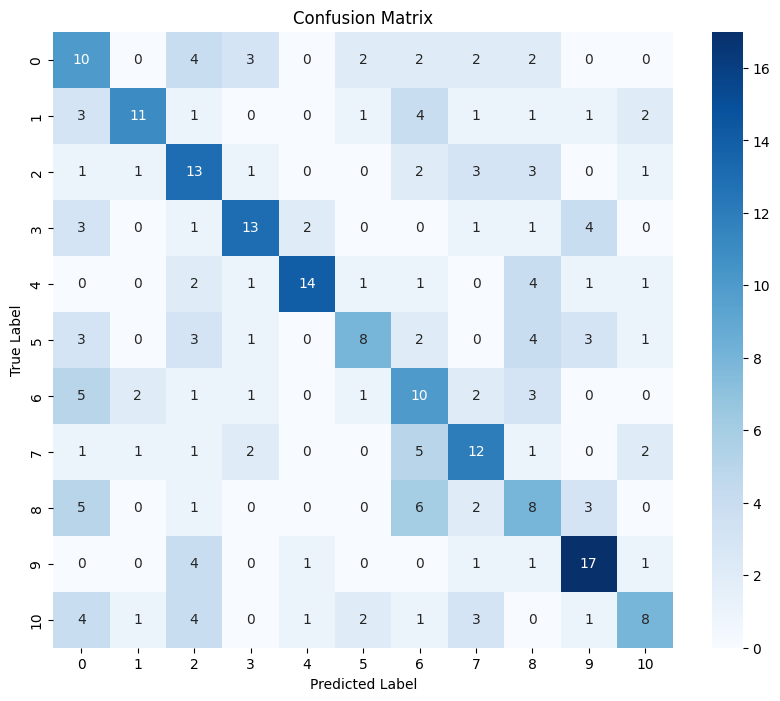

Classification Report:
               precision    recall  f1-score   support

    apple_pie       0.29      0.40      0.33        25
   cheesecake       0.69      0.44      0.54        25
chicken_curry       0.37      0.52      0.43        25
 french_fries       0.59      0.52      0.55        25
   fried_rice       0.78      0.56      0.65        25
    hamburger       0.53      0.32      0.40        25
      hot_dog       0.30      0.40      0.34        25
    ice_cream       0.44      0.48      0.46        25
     omelette       0.29      0.32      0.30        25
        pizza       0.57      0.68      0.62        25
        sushi       0.50      0.32      0.39        25

     accuracy                           0.45       275
    macro avg       0.49      0.45      0.46       275
 weighted avg       0.49      0.45      0.46       275



In [106]:
test_model(model_path="model_bs64_lr0.005.pth", batch_size=64)


In [ ]:
# Residual Block for ResNet-like architecture
# The residual block is a building block for ResNet architectures. It allows gradients to flow through the network more easily, which can help with training deeper networks.
# It consists of two convolutional layers with batch normalization and ReLU activation, along with a skip connection that adds the input to the output of the block.

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # If the input and output channels are different, we need to adjust the dimensions using a 1x1 convolution
        self.skip = nn.Sequential()
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)


In [33]:
# Residual CNN Model
# The ResidualCNN class is a convolutional neural network that uses residual blocks to improve training and performance.
# It consists of several convolutional layers followed by residual blocks, batch normalization, ReLU activation, and max pooling layers.
# The final layers include an adaptive average pooling layer and two fully connected layers with dropout for regularization.

class ResidualCNN(nn.Module):
    def __init__(self, num_classes=11):
        super(ResidualCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.res_block1 = ResidualBlock(64, 64)

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.res_block2 = ResidualBlock(128, 128)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.res_block1(x)
        x = self.layer3(x)
        x = self.res_block2(x)
        x = self.gap(x)
        x = self.fc(x)
        return x


In [ ]:
def RunResidualCNN():
    learning_rates = [0.001, 0.005, 0.01]
    batch_sizes = [32, 64]
    num_epochs = 50
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    results = []

    print(f"\n Training model: RESIDUAL CNN\n")

    for batch_size in batch_sizes:
        for lr in learning_rates:
            print(f"\n Batch Size={batch_size},  Learning Rate={lr}")

            # Data loaders
            train_loader, val_loader, _ = get_data_loaders(batch_size, num_workers=2)

            # Model creation
            model = ResidualCNN(num_classes=11)
            model.to(device)

            save_path = f"residual_bs{batch_size}_lr{lr}.pth"

            # Training
            train_acc, val_acc, best_val_acc = train_model(
                model,
                train_loader,
                val_loader,
                epochs=num_epochs,
                learning_rate=lr,
                save_path=save_path,
                device=device
            )

            # Store results
            results.append({
                "model": "residual",
                "batch_size": batch_size,
                "learning_rate": lr,
                "train_acc_list": train_acc,
                "val_acc_list": val_acc,
                "best_val_acc": best_val_acc
            })



In [66]:
RunResidualCNN()


 Training model: RESIDUAL CNN


 Batch Size=32,  Learning Rate=0.001
Epoch [1/50], Loss: 2.2932, Train Acc: 0.1200, Val Acc: 0.2073
Epoch [2/50], Loss: 2.1768, Train Acc: 0.2123, Val Acc: 0.1564
Epoch [3/50], Loss: 2.1273, Train Acc: 0.2236, Val Acc: 0.2109
Epoch [4/50], Loss: 2.0707, Train Acc: 0.2245, Val Acc: 0.1891
Epoch [5/50], Loss: 2.4165, Train Acc: 0.2491, Val Acc: 0.1891
Epoch [6/50], Loss: 2.0581, Train Acc: 0.2564, Val Acc: 0.2800
Epoch [7/50], Loss: 2.1684, Train Acc: 0.2691, Val Acc: 0.3491
Epoch [8/50], Loss: 2.0921, Train Acc: 0.2905, Val Acc: 0.2255
Epoch [9/50], Loss: 2.0324, Train Acc: 0.2805, Val Acc: 0.3055
Epoch [10/50], Loss: 2.0636, Train Acc: 0.3055, Val Acc: 0.3418
Epoch [11/50], Loss: 1.7220, Train Acc: 0.3141, Val Acc: 0.3091
Epoch [12/50], Loss: 1.8843, Train Acc: 0.3200, Val Acc: 0.3382
Epoch [13/50], Loss: 1.9280, Train Acc: 0.3277, Val Acc: 0.3309
Epoch [14/50], Loss: 1.6798, Train Acc: 0.3409, Val Acc: 0.2545
Epoch [15/50], Loss: 2.0994, Train Acc: 0.3

In [36]:
# Testing and evaluation for ResidualCNN
def test_residual(model_path="residual_bs16_lr0.005.pth", batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # just take the test loader
    _, _, test_loader = get_data_loaders(batch_size, num_workers=2)

    # Use ResidualCNN model instead of CNN
    model = ResidualCNN(num_classes=11)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n Test Accuracy: {acc:.4f}")

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=[
        'apple_pie', 'cheesecake', 'chicken_curry', 'french_fries',
        'fried_rice', 'hamburger', 'hot_dog', 'ice_cream',
        'omelette', 'pizza', 'sushi'
    ]))


C:\Users\YusufEmirComert\AppData\Local\Temp\ipykernel_20080\1012019867.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_


 Test Accuracy: 0.4364


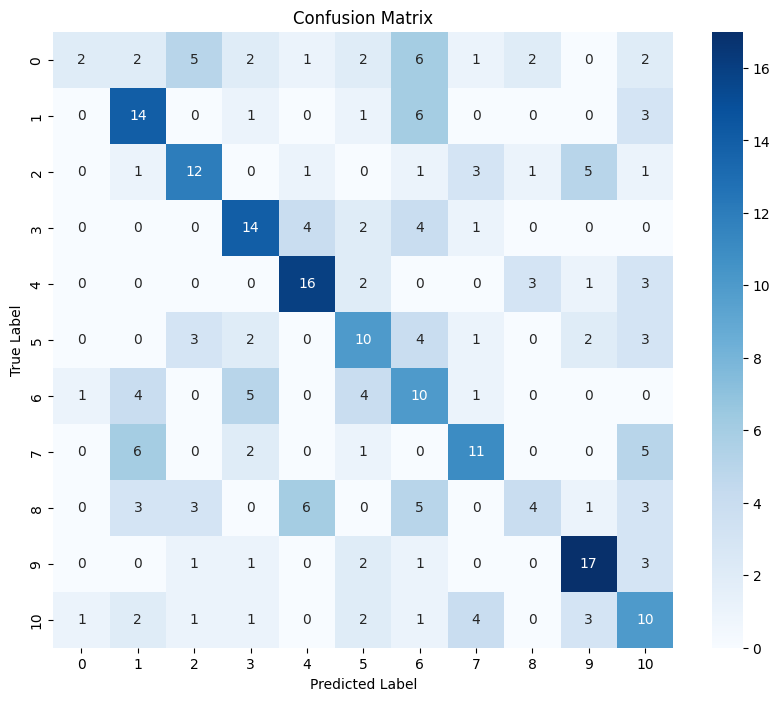

Classification Report:
               precision    recall  f1-score   support

    apple_pie       0.50      0.08      0.14        25
   cheesecake       0.44      0.56      0.49        25
chicken_curry       0.48      0.48      0.48        25
 french_fries       0.50      0.56      0.53        25
   fried_rice       0.57      0.64      0.60        25
    hamburger       0.38      0.40      0.39        25
      hot_dog       0.26      0.40      0.32        25
    ice_cream       0.50      0.44      0.47        25
     omelette       0.40      0.16      0.23        25
        pizza       0.59      0.68      0.63        25
        sushi       0.30      0.40      0.34        25

     accuracy                           0.44       275
    macro avg       0.45      0.44      0.42       275
 weighted avg       0.45      0.44      0.42       275



In [113]:
# Running the best model accoring to the validation accuracy
test_residual(model_path="residual_bs32_lr0.001.pth", batch_size=32)


PART 2 - TRANSFER LEARNING

In [ ]:
def RunTransferLearning():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    learning_rates = [0.001, 0.005, 0.01] # Learning rates to test
    batch_sizes = [32, 64] # Batch sizes to test
    num_epochs = 50  # 50 epochs for training

    results = []
    # 2 cases: fc_only and fc_and_last2conv
    # fc_only: only the fully connected layer is trained
    # fc_and_last2conv: the last two convolutional layers are also trained
    # The rest of the layers are frozen (not trained)
    for case in ["fc_only", "fc_and_last2conv"]:
        print(f"\nTraining Case: {case.upper()}")

        for batch_size in batch_sizes:
            for lr in learning_rates:
                print(f"\nBatch Size={batch_size},  Learning Rate={lr}")

                # Load data
                train_loader, val_loader, test_loader = get_data_loaders(batch_size=batch_size, num_workers=2)

                # Load pre-trained model
                model = models.mobilenet_v2(pretrained=True)

                # Freeze all layers first
                for param in model.parameters():
                    param.requires_grad = False

                # Unfreeze depending on case
                if case == "fc_and_last2conv":
                    for param in model.features[-1].parameters():
                        param.requires_grad = True
                    for param in model.features[-2].parameters():
                        param.requires_grad = True

                # Replace FC layer
                num_ftrs = model.classifier[1].in_features
                model.classifier[1] = nn.Linear(num_ftrs, 11)

                # FC layer requires grad
                for param in model.classifier[1].parameters():
                    param.requires_grad = True

                model = model.to(device)

                # Optimizer
                optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
                criterion = nn.CrossEntropyLoss()

                best_val_acc = 0
                train_acc_list = []
                val_acc_list = []

                # Training loop
                for epoch in range(num_epochs):
                    model.train()
                    correct_train = 0
                    total_train = 0

                    for images, labels in train_loader:
                        images, labels = images.to(device), labels.to(device)

                        optimizer.zero_grad()
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                        loss.backward()
                        optimizer.step()

                        _, predicted = torch.max(outputs, 1)
                        total_train += labels.size(0)
                        correct_train += (predicted == labels).sum().item()

                    train_acc = correct_train / total_train
                    train_acc_list.append(train_acc)

                    # Validation
                    val_acc = evaluate_model(model, val_loader, device)
                    val_acc_list.append(val_acc)

                    if val_acc > best_val_acc:
                        best_val_acc = val_acc
                        torch.save(model.state_dict(), f"{case}_bs{batch_size}_lr{lr}.pth")

                    print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

                # Test accuracy + confusion matrix
                test_acc, y_true, y_pred = test_model(model, test_loader, device)
                print(f"Test Accuracy: {test_acc:.4f}")

                # Confusion matrix plot
                cm = confusion_matrix(y_true, y_pred)
                plt.figure(figsize=(8, 6))
                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
                plt.title(f"Confusion Matrix ({case}, BS={batch_size}, LR={lr})")
                plt.xlabel("Predicted")
                plt.ylabel("True")
                plt.show()

                # Store results
                results.append({
                    "case": case,
                    "batch_size": batch_size,
                    "learning_rate": lr,
                    "train_acc_list": train_acc_list,
                    "val_acc_list": val_acc_list,
                    "test_acc": test_acc
                })

    return results


In [ ]:
#  Evaluation helper
def evaluate_model(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total



In [40]:
#  Test helper
def test_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc, all_labels, all_preds



Training Case: FC_ONLY

Batch Size=32,  Learning Rate=0.001


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.4282, Val Acc: 0.7455
Epoch [2/50], Train Acc: 0.6564, Val Acc: 0.7818
Epoch [3/50], Train Acc: 0.7200, Val Acc: 0.8073
Epoch [4/50], Train Acc: 0.7559, Val Acc: 0.8073
Epoch [5/50], Train Acc: 0.7591, Val Acc: 0.8182
Epoch [6/50], Train Acc: 0.7700, Val Acc: 0.7855
Epoch [7/50], Train Acc: 0.7864, Val Acc: 0.8218
Epoch [8/50], Train Acc: 0.7914, Val Acc: 0.8109
Epoch [9/50], Train Acc: 0.8014, Val Acc: 0.7891
Epoch [10/50], Train Acc: 0.8018, Val Acc: 0.7964
Epoch [11/50], Train Acc: 0.8077, Val Acc: 0.7709
Epoch [12/50], Train Acc: 0.8050, Val Acc: 0.7891
Epoch [13/50], Train Acc: 0.8195, Val Acc: 0.8145
Epoch [14/50], Train Acc: 0.8164, Val Acc: 0.8218
Epoch [15/50], Train Acc: 0.8355, Val Acc: 0.8145
Epoch [16/50], Train Acc: 0.8259, Val Acc: 0.8109
Epoch [17/50], Train Acc: 0.8273, Val Acc: 0.8000
Epoch [18/50], Train Acc: 0.8264, Val Acc: 0.8000
Epoch [19/50], Train Acc: 0.8445, Val Acc: 0.8036
Epoch [20/50], Train Acc: 0.8368, Val Acc: 0.8145
Epoch [21

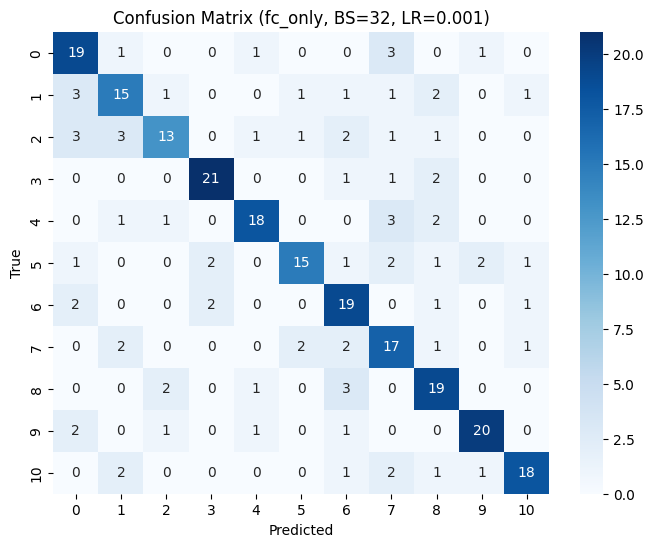


Batch Size=32,  Learning Rate=0.005


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.5168, Val Acc: 0.7455
Epoch [2/50], Train Acc: 0.6900, Val Acc: 0.7782
Epoch [3/50], Train Acc: 0.7236, Val Acc: 0.8000
Epoch [4/50], Train Acc: 0.7314, Val Acc: 0.7745
Epoch [5/50], Train Acc: 0.7577, Val Acc: 0.7964
Epoch [6/50], Train Acc: 0.7482, Val Acc: 0.7564
Epoch [7/50], Train Acc: 0.7559, Val Acc: 0.7636
Epoch [8/50], Train Acc: 0.7641, Val Acc: 0.8036
Epoch [9/50], Train Acc: 0.7809, Val Acc: 0.7564
Epoch [10/50], Train Acc: 0.7595, Val Acc: 0.7855
Epoch [11/50], Train Acc: 0.7964, Val Acc: 0.7782
Epoch [12/50], Train Acc: 0.7727, Val Acc: 0.7964
Epoch [13/50], Train Acc: 0.8118, Val Acc: 0.8036
Epoch [14/50], Train Acc: 0.8005, Val Acc: 0.7491
Epoch [15/50], Train Acc: 0.7955, Val Acc: 0.7636
Epoch [16/50], Train Acc: 0.8223, Val Acc: 0.8000
Epoch [17/50], Train Acc: 0.8173, Val Acc: 0.8000
Epoch [18/50], Train Acc: 0.8141, Val Acc: 0.7927
Epoch [19/50], Train Acc: 0.8155, Val Acc: 0.7818
Epoch [20/50], Train Acc: 0.8377, Val Acc: 0.7564
Epoch [21

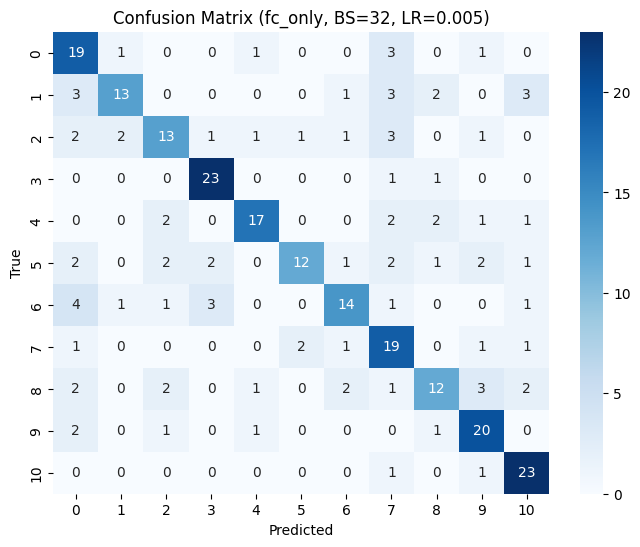


Batch Size=32,  Learning Rate=0.01


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.4759, Val Acc: 0.7236
Epoch [2/50], Train Acc: 0.6636, Val Acc: 0.7455
Epoch [3/50], Train Acc: 0.6777, Val Acc: 0.6945
Epoch [4/50], Train Acc: 0.6973, Val Acc: 0.7455
Epoch [5/50], Train Acc: 0.7159, Val Acc: 0.7491
Epoch [6/50], Train Acc: 0.7427, Val Acc: 0.7309
Epoch [7/50], Train Acc: 0.7368, Val Acc: 0.7091
Epoch [8/50], Train Acc: 0.7532, Val Acc: 0.7455
Epoch [9/50], Train Acc: 0.7532, Val Acc: 0.7127
Epoch [10/50], Train Acc: 0.7791, Val Acc: 0.7345
Epoch [11/50], Train Acc: 0.7727, Val Acc: 0.7527
Epoch [12/50], Train Acc: 0.7645, Val Acc: 0.7636
Epoch [13/50], Train Acc: 0.7909, Val Acc: 0.7382
Epoch [14/50], Train Acc: 0.7727, Val Acc: 0.7673
Epoch [15/50], Train Acc: 0.7818, Val Acc: 0.7527
Epoch [16/50], Train Acc: 0.7773, Val Acc: 0.7673
Epoch [17/50], Train Acc: 0.7659, Val Acc: 0.7491
Epoch [18/50], Train Acc: 0.8059, Val Acc: 0.7709
Epoch [19/50], Train Acc: 0.8105, Val Acc: 0.7636
Epoch [20/50], Train Acc: 0.7936, Val Acc: 0.7382
Epoch [21

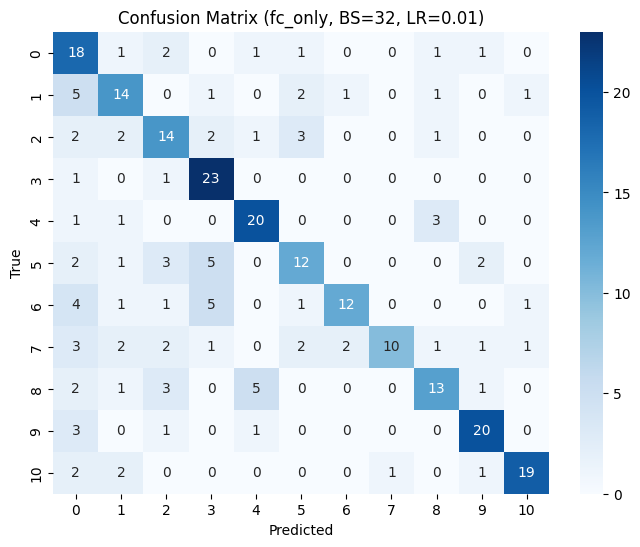


Batch Size=64,  Learning Rate=0.001


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.3986, Val Acc: 0.7382
Epoch [2/50], Train Acc: 0.6600, Val Acc: 0.7927
Epoch [3/50], Train Acc: 0.7141, Val Acc: 0.7964
Epoch [4/50], Train Acc: 0.7468, Val Acc: 0.8109
Epoch [5/50], Train Acc: 0.7464, Val Acc: 0.8145
Epoch [6/50], Train Acc: 0.7709, Val Acc: 0.8073
Epoch [7/50], Train Acc: 0.7855, Val Acc: 0.8218
Epoch [8/50], Train Acc: 0.7823, Val Acc: 0.8364
Epoch [9/50], Train Acc: 0.7995, Val Acc: 0.8182
Epoch [10/50], Train Acc: 0.8036, Val Acc: 0.8036
Epoch [11/50], Train Acc: 0.8227, Val Acc: 0.8000
Epoch [12/50], Train Acc: 0.8273, Val Acc: 0.8109
Epoch [13/50], Train Acc: 0.8286, Val Acc: 0.7855
Epoch [14/50], Train Acc: 0.8364, Val Acc: 0.8255
Epoch [15/50], Train Acc: 0.8500, Val Acc: 0.8182
Epoch [16/50], Train Acc: 0.8314, Val Acc: 0.8073
Epoch [17/50], Train Acc: 0.8395, Val Acc: 0.8036
Epoch [18/50], Train Acc: 0.8523, Val Acc: 0.8036
Epoch [19/50], Train Acc: 0.8464, Val Acc: 0.7891
Epoch [20/50], Train Acc: 0.8559, Val Acc: 0.8145
Epoch [21

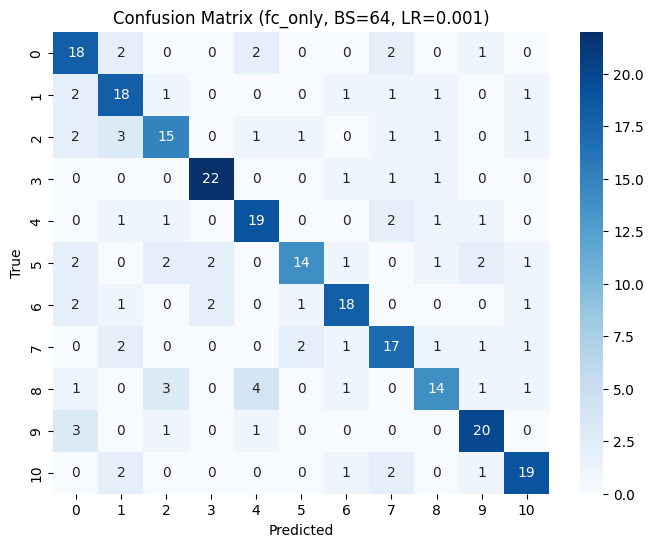


Batch Size=64,  Learning Rate=0.005


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.4800, Val Acc: 0.7236
Epoch [2/50], Train Acc: 0.6977, Val Acc: 0.7745
Epoch [3/50], Train Acc: 0.7464, Val Acc: 0.7455
Epoch [4/50], Train Acc: 0.7773, Val Acc: 0.7818
Epoch [5/50], Train Acc: 0.7927, Val Acc: 0.8255
Epoch [6/50], Train Acc: 0.8050, Val Acc: 0.7855
Epoch [7/50], Train Acc: 0.8118, Val Acc: 0.7745
Epoch [8/50], Train Acc: 0.8200, Val Acc: 0.7818
Epoch [9/50], Train Acc: 0.8245, Val Acc: 0.7964
Epoch [10/50], Train Acc: 0.8186, Val Acc: 0.8073
Epoch [11/50], Train Acc: 0.8250, Val Acc: 0.7891
Epoch [12/50], Train Acc: 0.8318, Val Acc: 0.7891
Epoch [13/50], Train Acc: 0.8332, Val Acc: 0.8073
Epoch [14/50], Train Acc: 0.8505, Val Acc: 0.8073
Epoch [15/50], Train Acc: 0.8568, Val Acc: 0.7818
Epoch [16/50], Train Acc: 0.8477, Val Acc: 0.7964
Epoch [17/50], Train Acc: 0.8568, Val Acc: 0.7709
Epoch [18/50], Train Acc: 0.8459, Val Acc: 0.7564
Epoch [19/50], Train Acc: 0.8782, Val Acc: 0.8036
Epoch [20/50], Train Acc: 0.8695, Val Acc: 0.7745
Epoch [21

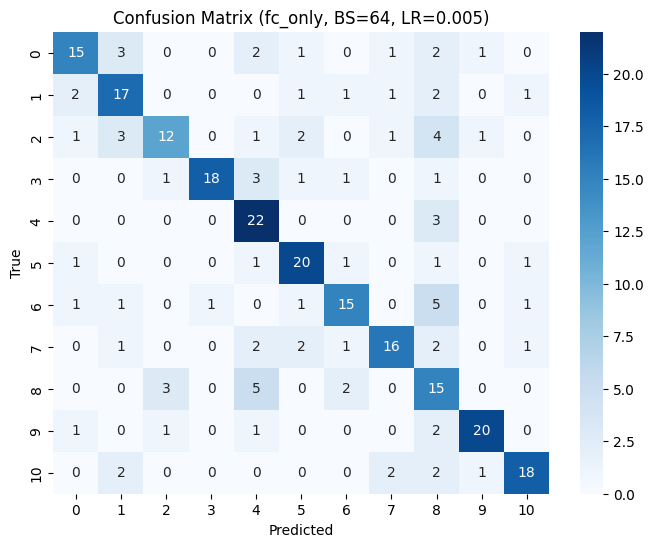


Batch Size=64,  Learning Rate=0.01


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.4059, Val Acc: 0.7418
Epoch [2/50], Train Acc: 0.6936, Val Acc: 0.7491
Epoch [3/50], Train Acc: 0.7486, Val Acc: 0.7600
Epoch [4/50], Train Acc: 0.7664, Val Acc: 0.7309
Epoch [5/50], Train Acc: 0.7623, Val Acc: 0.7491
Epoch [6/50], Train Acc: 0.7364, Val Acc: 0.7127
Epoch [7/50], Train Acc: 0.7723, Val Acc: 0.7455
Epoch [8/50], Train Acc: 0.7923, Val Acc: 0.7673
Epoch [9/50], Train Acc: 0.7964, Val Acc: 0.7927
Epoch [10/50], Train Acc: 0.7945, Val Acc: 0.7927
Epoch [11/50], Train Acc: 0.8059, Val Acc: 0.7673
Epoch [12/50], Train Acc: 0.8114, Val Acc: 0.7455
Epoch [13/50], Train Acc: 0.8086, Val Acc: 0.7636
Epoch [14/50], Train Acc: 0.8305, Val Acc: 0.7673
Epoch [15/50], Train Acc: 0.8418, Val Acc: 0.7709
Epoch [16/50], Train Acc: 0.8132, Val Acc: 0.7564
Epoch [17/50], Train Acc: 0.8205, Val Acc: 0.7709
Epoch [18/50], Train Acc: 0.8273, Val Acc: 0.7345
Epoch [19/50], Train Acc: 0.8255, Val Acc: 0.7564
Epoch [20/50], Train Acc: 0.8436, Val Acc: 0.7345
Epoch [21

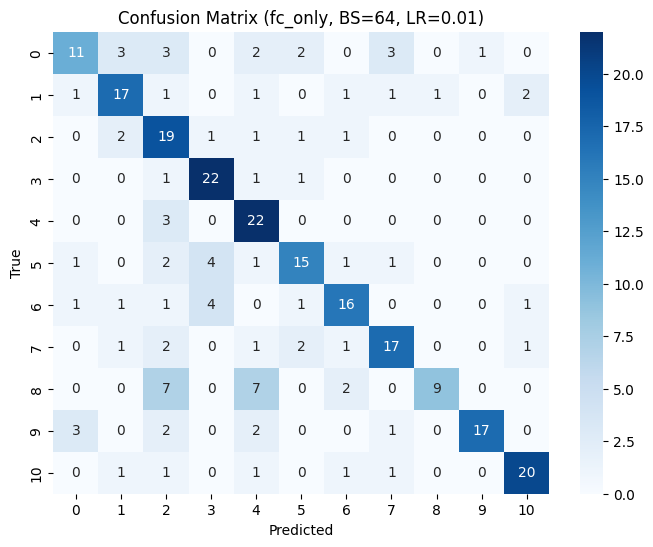


Training Case: FC_AND_LAST2CONV

Batch Size=32,  Learning Rate=0.001


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.6118, Val Acc: 0.8109
Epoch [2/50], Train Acc: 0.8009, Val Acc: 0.8182
Epoch [3/50], Train Acc: 0.8491, Val Acc: 0.8255
Epoch [4/50], Train Acc: 0.8973, Val Acc: 0.8000
Epoch [5/50], Train Acc: 0.9395, Val Acc: 0.8109
Epoch [6/50], Train Acc: 0.9459, Val Acc: 0.7818
Epoch [7/50], Train Acc: 0.9477, Val Acc: 0.8073
Epoch [8/50], Train Acc: 0.9586, Val Acc: 0.8255
Epoch [9/50], Train Acc: 0.9695, Val Acc: 0.8255
Epoch [10/50], Train Acc: 0.9564, Val Acc: 0.8000
Epoch [11/50], Train Acc: 0.9645, Val Acc: 0.8618
Epoch [12/50], Train Acc: 0.9750, Val Acc: 0.8145
Epoch [13/50], Train Acc: 0.9800, Val Acc: 0.8255
Epoch [14/50], Train Acc: 0.9814, Val Acc: 0.8073
Epoch [15/50], Train Acc: 0.9868, Val Acc: 0.8145
Epoch [16/50], Train Acc: 0.9877, Val Acc: 0.8400
Epoch [17/50], Train Acc: 0.9823, Val Acc: 0.8473
Epoch [18/50], Train Acc: 0.9895, Val Acc: 0.8182
Epoch [19/50], Train Acc: 0.9886, Val Acc: 0.8291
Epoch [20/50], Train Acc: 0.9864, Val Acc: 0.8109
Epoch [21

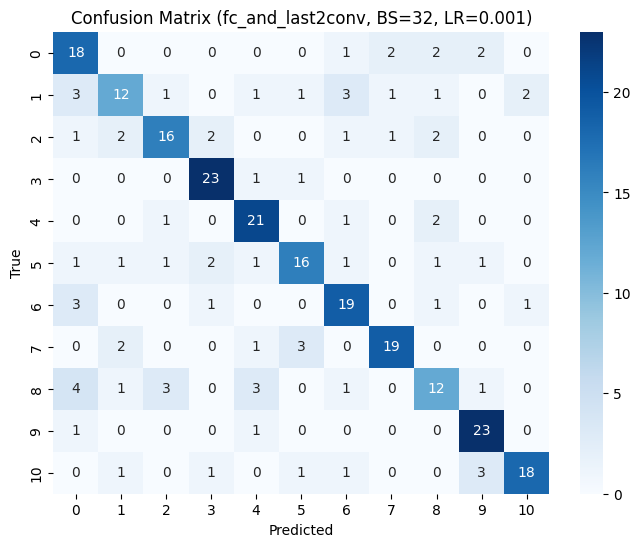


Batch Size=32,  Learning Rate=0.005


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.5641, Val Acc: 0.7382
Epoch [2/50], Train Acc: 0.6986, Val Acc: 0.7964
Epoch [3/50], Train Acc: 0.7623, Val Acc: 0.7891
Epoch [4/50], Train Acc: 0.8018, Val Acc: 0.7818
Epoch [5/50], Train Acc: 0.8318, Val Acc: 0.8036
Epoch [6/50], Train Acc: 0.8618, Val Acc: 0.7673
Epoch [7/50], Train Acc: 0.8995, Val Acc: 0.7782
Epoch [8/50], Train Acc: 0.8914, Val Acc: 0.7782
Epoch [9/50], Train Acc: 0.9127, Val Acc: 0.7855
Epoch [10/50], Train Acc: 0.9073, Val Acc: 0.7709
Epoch [11/50], Train Acc: 0.9059, Val Acc: 0.7636
Epoch [12/50], Train Acc: 0.9186, Val Acc: 0.7455
Epoch [13/50], Train Acc: 0.9223, Val Acc: 0.7600
Epoch [14/50], Train Acc: 0.9432, Val Acc: 0.8036
Epoch [15/50], Train Acc: 0.9482, Val Acc: 0.8036
Epoch [16/50], Train Acc: 0.9541, Val Acc: 0.7782
Epoch [17/50], Train Acc: 0.9614, Val Acc: 0.7745
Epoch [18/50], Train Acc: 0.9509, Val Acc: 0.8000
Epoch [19/50], Train Acc: 0.9459, Val Acc: 0.7782
Epoch [20/50], Train Acc: 0.9700, Val Acc: 0.7636
Epoch [21

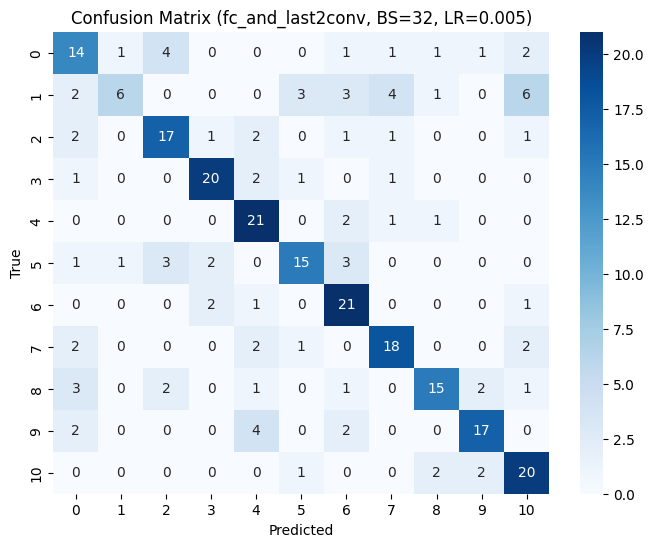


Batch Size=32,  Learning Rate=0.01


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.4941, Val Acc: 0.7273
Epoch [2/50], Train Acc: 0.6850, Val Acc: 0.7782
Epoch [3/50], Train Acc: 0.7514, Val Acc: 0.8145
Epoch [4/50], Train Acc: 0.7668, Val Acc: 0.6982
Epoch [5/50], Train Acc: 0.8009, Val Acc: 0.8073
Epoch [6/50], Train Acc: 0.8223, Val Acc: 0.7382
Epoch [7/50], Train Acc: 0.8405, Val Acc: 0.7418
Epoch [8/50], Train Acc: 0.8495, Val Acc: 0.7673
Epoch [9/50], Train Acc: 0.8773, Val Acc: 0.8073
Epoch [10/50], Train Acc: 0.8841, Val Acc: 0.7964
Epoch [11/50], Train Acc: 0.9000, Val Acc: 0.7891
Epoch [12/50], Train Acc: 0.9068, Val Acc: 0.8000
Epoch [13/50], Train Acc: 0.9209, Val Acc: 0.8000
Epoch [14/50], Train Acc: 0.9145, Val Acc: 0.7891
Epoch [15/50], Train Acc: 0.9295, Val Acc: 0.7927
Epoch [16/50], Train Acc: 0.9291, Val Acc: 0.7782
Epoch [17/50], Train Acc: 0.9423, Val Acc: 0.8109
Epoch [18/50], Train Acc: 0.9318, Val Acc: 0.8255
Epoch [19/50], Train Acc: 0.9332, Val Acc: 0.7745
Epoch [20/50], Train Acc: 0.9464, Val Acc: 0.8109
Epoch [21

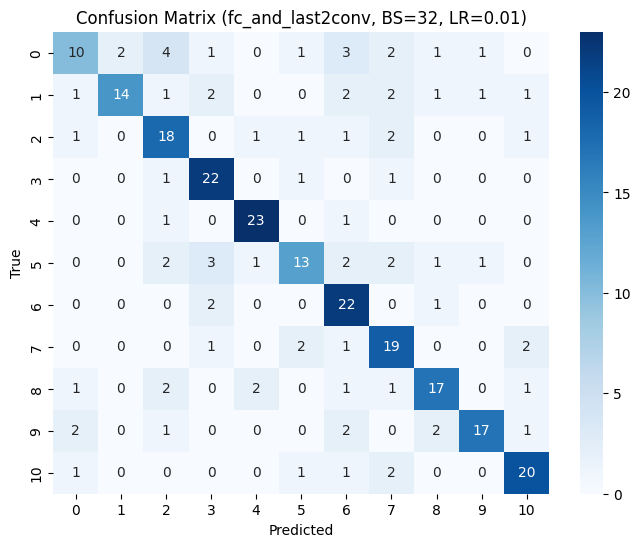


Batch Size=64,  Learning Rate=0.001


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.6095, Val Acc: 0.8145
Epoch [2/50], Train Acc: 0.8273, Val Acc: 0.8473
Epoch [3/50], Train Acc: 0.9123, Val Acc: 0.8291
Epoch [4/50], Train Acc: 0.9436, Val Acc: 0.7891
Epoch [5/50], Train Acc: 0.9641, Val Acc: 0.8291
Epoch [6/50], Train Acc: 0.9814, Val Acc: 0.8000
Epoch [7/50], Train Acc: 0.9900, Val Acc: 0.8218
Epoch [8/50], Train Acc: 0.9895, Val Acc: 0.8255
Epoch [9/50], Train Acc: 0.9900, Val Acc: 0.8291
Epoch [10/50], Train Acc: 0.9932, Val Acc: 0.8145
Epoch [11/50], Train Acc: 0.9923, Val Acc: 0.7855
Epoch [12/50], Train Acc: 0.9855, Val Acc: 0.8109
Epoch [13/50], Train Acc: 0.9859, Val Acc: 0.8000
Epoch [14/50], Train Acc: 0.9895, Val Acc: 0.8218
Epoch [15/50], Train Acc: 0.9836, Val Acc: 0.8145
Epoch [16/50], Train Acc: 0.9891, Val Acc: 0.7964
Epoch [17/50], Train Acc: 0.9886, Val Acc: 0.8036
Epoch [18/50], Train Acc: 0.9845, Val Acc: 0.8218
Epoch [19/50], Train Acc: 0.9795, Val Acc: 0.8255
Epoch [20/50], Train Acc: 0.9823, Val Acc: 0.8000
Epoch [21

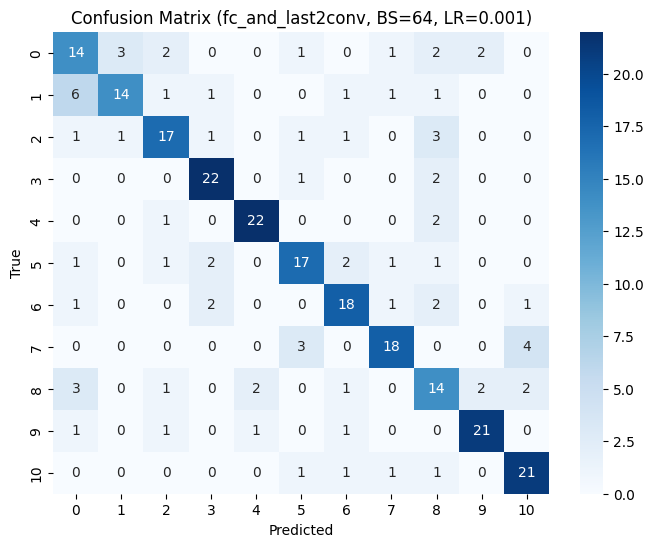


Batch Size=64,  Learning Rate=0.005


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.5523, Val Acc: 0.7600
Epoch [2/50], Train Acc: 0.7673, Val Acc: 0.8582
Epoch [3/50], Train Acc: 0.8277, Val Acc: 0.7709
Epoch [4/50], Train Acc: 0.8564, Val Acc: 0.7709
Epoch [5/50], Train Acc: 0.8991, Val Acc: 0.8291
Epoch [6/50], Train Acc: 0.9173, Val Acc: 0.8073
Epoch [7/50], Train Acc: 0.9127, Val Acc: 0.7491
Epoch [8/50], Train Acc: 0.9191, Val Acc: 0.7745
Epoch [9/50], Train Acc: 0.9209, Val Acc: 0.8000
Epoch [10/50], Train Acc: 0.9336, Val Acc: 0.7673
Epoch [11/50], Train Acc: 0.9505, Val Acc: 0.7964
Epoch [12/50], Train Acc: 0.9609, Val Acc: 0.8036
Epoch [13/50], Train Acc: 0.9641, Val Acc: 0.8255
Epoch [14/50], Train Acc: 0.9759, Val Acc: 0.8327
Epoch [15/50], Train Acc: 0.9645, Val Acc: 0.8182
Epoch [16/50], Train Acc: 0.9500, Val Acc: 0.8036
Epoch [17/50], Train Acc: 0.9477, Val Acc: 0.7964
Epoch [18/50], Train Acc: 0.9573, Val Acc: 0.8036
Epoch [19/50], Train Acc: 0.9714, Val Acc: 0.8109
Epoch [20/50], Train Acc: 0.9632, Val Acc: 0.7964
Epoch [21

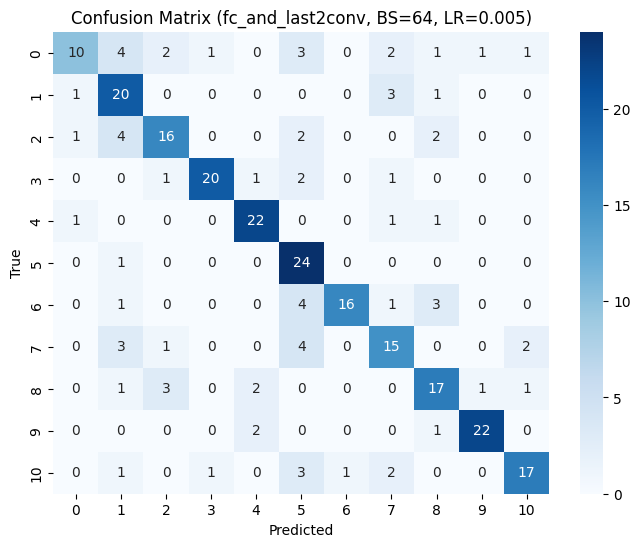


Batch Size=64,  Learning Rate=0.01


C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\YusufEmirComert\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/50], Train Acc: 0.5109, Val Acc: 0.7745
Epoch [2/50], Train Acc: 0.7323, Val Acc: 0.7673
Epoch [3/50], Train Acc: 0.7845, Val Acc: 0.7636
Epoch [4/50], Train Acc: 0.8214, Val Acc: 0.7818
Epoch [5/50], Train Acc: 0.8486, Val Acc: 0.7927
Epoch [6/50], Train Acc: 0.8632, Val Acc: 0.7673
Epoch [7/50], Train Acc: 0.8700, Val Acc: 0.7564
Epoch [8/50], Train Acc: 0.8895, Val Acc: 0.7818
Epoch [9/50], Train Acc: 0.9200, Val Acc: 0.7891
Epoch [10/50], Train Acc: 0.9155, Val Acc: 0.7964
Epoch [11/50], Train Acc: 0.9200, Val Acc: 0.8255
Epoch [12/50], Train Acc: 0.9355, Val Acc: 0.7636
Epoch [13/50], Train Acc: 0.9423, Val Acc: 0.8036
Epoch [14/50], Train Acc: 0.9386, Val Acc: 0.8182
Epoch [15/50], Train Acc: 0.9645, Val Acc: 0.7964
Epoch [16/50], Train Acc: 0.9509, Val Acc: 0.7745
Epoch [17/50], Train Acc: 0.9405, Val Acc: 0.7491
Epoch [18/50], Train Acc: 0.9673, Val Acc: 0.8000
Epoch [19/50], Train Acc: 0.9673, Val Acc: 0.8036
Epoch [20/50], Train Acc: 0.9527, Val Acc: 0.7964
Epoch [21

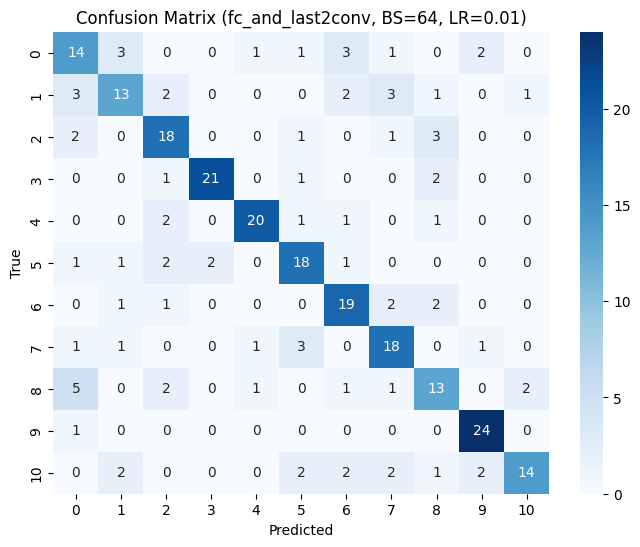

In [41]:
results = RunTransferLearning()
